In [1]:
"""
"ext" (7-dim, qS/phiS-extended) counterpart of paris3_sc.py.

Same source, LogLike, and S6 semi-coherent scoring as paris3_lhs_s6_ext.py
(which precomputed the LHS seed at /scratch/e1498138/paper/ext/paris3_lhs_s6/lhs_s6.pkl).
Runs a ParisMC search over the 7-dim (logm1, logm2, a, p0, e0, qS, phiS) box,
using that LHS grid (and its ellipsoid prior bounds) as the external seed.
"""
import numpy as np
import few
import os
import sys
import pickle

dir_work = '/home/svu/e1498138/emri_search/work/'
os.chdir(dir_work)
sys.path.insert(0, dir_work)

from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
from loglike_timemax_noise import LogLike
# sys.path.insert(0, "/nfs/home/svu/e1498138/parismc_dev")

import parismc
import cupy as cp

cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
dt = 10
T = 23/12 #NOTE: changed!
N_SEGS = 6
print(f"Using dt={dt}s, T={T}yr, TDI gen={tdi_gen}, N_segs={N_SEGS}")

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=True, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

# # Source (matches paper/ext/stage1_anneal.ipynb / paris3_lhs_s6_ext.py)
# m1, m2, a, p0, e0, xI0 = 1e6, 1e1, 0.7, 9.0, 0.4, 1.0
# dist, qS, phiS, qK, phiK = 4.5, np.pi, 0., 0., 0.
# Phi_phi0, Phi_theta0, Phi_r0 = 0.4, 0.0, 0.5

# Source (Mojito light EMRI_G, matches paris2_sc_ext.py)

# m1 = 6.72e5
# m2 = 9.84e1
# a = 0.5
# p0 = 15.7117
# e0 = 0.7440
# xI0 = 1.0
# dist = 4.755
# qS = 0.5906
# phiS = 3.5808
# qK = 1.1707
# phiK = 3.8495
# Phi_phi0 = 3.1940
# Phi_theta0 = 3.3780
# Phi_r0 = 0.6038


def icrs_to_ecliptic(qK_icrs, phiK_icrs, eps_deg=23.43929111):
    """
    Convert a sky direction (colatitude, longitude) from the ICRS/equatorial
    frame (qK = pi/2 - dec, phiK = ra) to the ecliptic frame (SSB frame used
    by the LISA response, is_ecliptic_latitude=False convention) via the
    standard equatorial<->ecliptic rotation with J2000 mean obliquity eps.
    """
    dec = np.pi / 2 - qK_icrs
    ra = phiK_icrs
    eps = np.deg2rad(eps_deg)

    sin_beta = np.sin(dec) * np.cos(eps) - np.cos(dec) * np.sin(ra) * np.sin(eps)
    beta = np.arcsin(sin_beta)

    y = np.cos(dec) * np.sin(ra) * np.cos(eps) + np.sin(dec) * np.sin(eps)
    x = np.cos(dec) * np.cos(ra)
    lam = np.arctan2(y, x) % (2 * np.pi)

    qK_ecl = np.pi / 2 - beta
    phiK_ecl = lam
    return qK_ecl, phiK_ecl

# Mojito light EMRI_C
m1 = 3.54e6
m2 = 8.01e1
a = 0.950
p0 = 7.3890
e0 = 0.3160
xI0 = 1.0000
dist = 4.858
qS = 2.0420
phiS = 5.7873
qK, phiK = icrs_to_ecliptic(1.6633, 1.7431)  # catalog qK/phiK are in ICRS, convert to ecliptic
Phi_phi0 = 2.4044
Phi_theta0 = 0.2850
Phi_r0 = 0.9743

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = [np.log10(m1), np.log10(m2), a, p0, e0, np.cos(qS), phiS]

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing LogLike...')
loglike_obj = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)
print('LogLike initialized.')


def log_density(params):
    params = np.asarray(params)
    out = np.full(params.shape[0], -np.inf)
    for i in range(params.shape[0]):
        logm1, logm2, a_i, p0_i, e0_i, cos_qS_i, phiS_i = params[i]
        try:
            qS_i = np.arccos(cos_qS_i)
            h_temp = gwf.xp.array(waveform_response(
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist, qS_i, phiS_i, qK, phiK,
                Phi_phi0, Phi_theta0, Phi_r0,
                T=T, dt=dt,
            ))
            out[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h_temp, N_seg=N_SEGS, phase_max=True))
        except Exception:
            pass
    return out



def prior_transform(u):
    # broad EMRI C (pre-anneal)
    # logm1lim = [6.15,  6.95]
    # logm2lim = [1.60,  2.20]
    # alim = [0.70,  0.999]
    # p0lim = [5.89,  8.89]
    # e0lim = [0.17,  0.47]
    # cosqSlim = [-1.0,  1.0]
    # phiSlim = [0.0,  2*np.pi]

    # EMRI C, matches lhs_sc_s6/final.pkl box (run_lhs_noise_sc_ext.py, "# EMRI_C")
    logm1lim = [6.54808, 6.54911]
    logm2lim = [1.90229, 1.90370]
    alim = [0.94932, 0.95003]
    p0lim = [7.38774, 7.39225]
    e0lim = [0.31562, 0.31965]
    cosqSlim = [-1.0, 1.0]
    phiSlim = [0.0, 2 * np.pi]

    t = np.zeros_like(u)
    t[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]
    t[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]
    t[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    t[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]
    t[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]
    t[:, 5] = (cosqSlim[1] - cosqSlim[0]) * u[:, 5] + cosqSlim[0]
    t[:, 6] = (phiSlim[1] - phiSlim[0]) * u[:, 6] + phiSlim[0]
    return t


def inverse_prior_transform(params):
    # EMRI C, matches lhs_sc_s6/final.pkl box (run_lhs_noise_sc_ext.py, "# EMRI_C")
    logm1lim = [6.54808, 6.54911]
    logm2lim = [1.90229, 1.90370]
    alim = [0.94932, 0.95003]
    p0lim = [7.38774, 7.39225]
    e0lim = [0.31562, 0.31965]
    cosqSlim = [-1.0, 1.0]
    phiSlim = [0.0, 2 * np.pi]

    params = np.asarray(params)
    u = np.zeros_like(params)
    u[:, 0] = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    u[:, 5] = (params[:, 5] - cosqSlim[0]) / (cosqSlim[1] - cosqSlim[0])
    u[:, 6] = (params[:, 6] - phiSlim[0]) / (phiSlim[1] - phiSlim[0])
    return u


Using dt=10s, T=1.9166666666666667yr, TDI gen=1, N_segs=6
Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing LogLike...
LogLike initialized.


In [2]:
dir_scratch = '/scratch/e1498138/'
savepath = dir_scratch + 'paper/ext/emri_c/stage2_merge_s6/'


In [3]:
sampler = parismc.Sampler.load_state(savepath+'/sampler_state.pkl')
samples, weights = sampler.get_samples_with_weights(flatten=True)
proc_pt = sampler.searched_points_list
logden_list = sampler.searched_log_densities_list


In [4]:
sampler.now_covariances

[array([[ 3.89010871e-03,  3.37647602e-03,  5.57723401e-03,
         -5.95181373e-03, -4.14602989e-03,  3.79027986e-04,
          1.56757480e-04],
        [ 3.37647602e-03,  3.40428761e-03,  4.98722702e-03,
         -4.44599837e-03, -4.41024092e-03,  4.06084718e-04,
          1.62135913e-04],
        [ 5.57723401e-03,  4.98722702e-03,  8.52770609e-03,
         -8.06381041e-03, -5.35591696e-03,  1.79794452e-04,
          2.07641103e-05],
        [-5.95181373e-03, -4.44599837e-03, -8.06381041e-03,
          1.04691178e-02,  5.77723840e-03, -4.16154476e-04,
         -2.45425230e-04],
        [-4.14602989e-03, -4.41024092e-03, -5.35591696e-03,
          5.77723840e-03,  7.75998710e-03, -9.62866646e-04,
         -6.03901324e-04],
        [ 3.79027986e-04,  4.06084718e-04,  1.79794452e-04,
         -4.16154476e-04, -9.62866646e-04,  2.45800595e-03,
          5.80184524e-04],
        [ 1.56757480e-04,  1.62135913e-04,  2.07641103e-05,
         -2.45425230e-04, -6.03901324e-04,  5.80184524e-04

In [5]:
len(sampler.now_covariances)

3

In [6]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1

array([[ 6.54901194,  1.90364114,  0.95000945,  7.38894413,  0.3159886 ,
        -0.36372673,  5.8297268 ]])

In [7]:
maxld_pt2 = prior_transform(proc_pt[1][np.argmax(logden_list)].reshape(1, -1))
maxld_pt2

array([[6.54894941, 1.90343259, 0.94998209, 7.38846499, 0.31585785,
        0.52352768, 2.63537629]])

In [8]:
maxld_pt3 = prior_transform(proc_pt[2][np.argmax(logden_list)].reshape(1, -1))
maxld_pt3

array([[6.54855523, 1.90288537, 0.94960338, 7.39041019, 0.31777174,
        0.59441612, 2.34006068]])

In [9]:
log_density(maxld_pt1)

array([122.29322678])

In [10]:
log_density(maxld_pt2)

array([74.62307263])

In [11]:
log_density(maxld_pt3)

array([109.80465174])

In [12]:
log_density([param_true])

array([123.50566243])

In [13]:
param_ranges = [(6.54808, 6.54911),
                (1.90229,  1.90370),
                (0.94932,  0.95003),
                (7.38774,  7.39225),
                (0.31562,  0.31965),
                (-1,1),
                (0.0, 2 * np.pi)
                ]
param_ranges



[(6.54808, 6.54911),
 (1.90229, 1.9037),
 (0.94932, 0.95003),
 (7.38774, 7.39225),
 (0.31562, 0.31965),
 (-1, 1),
 (0.0, 6.283185307179586)]

In [14]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0,np.cos(qS),phiS]
param_true

[6.549003262025788,
 1.9036325160842376,
 0.95,
 7.389,
 0.316,
 -0.45395911390155774,
 5.7873]

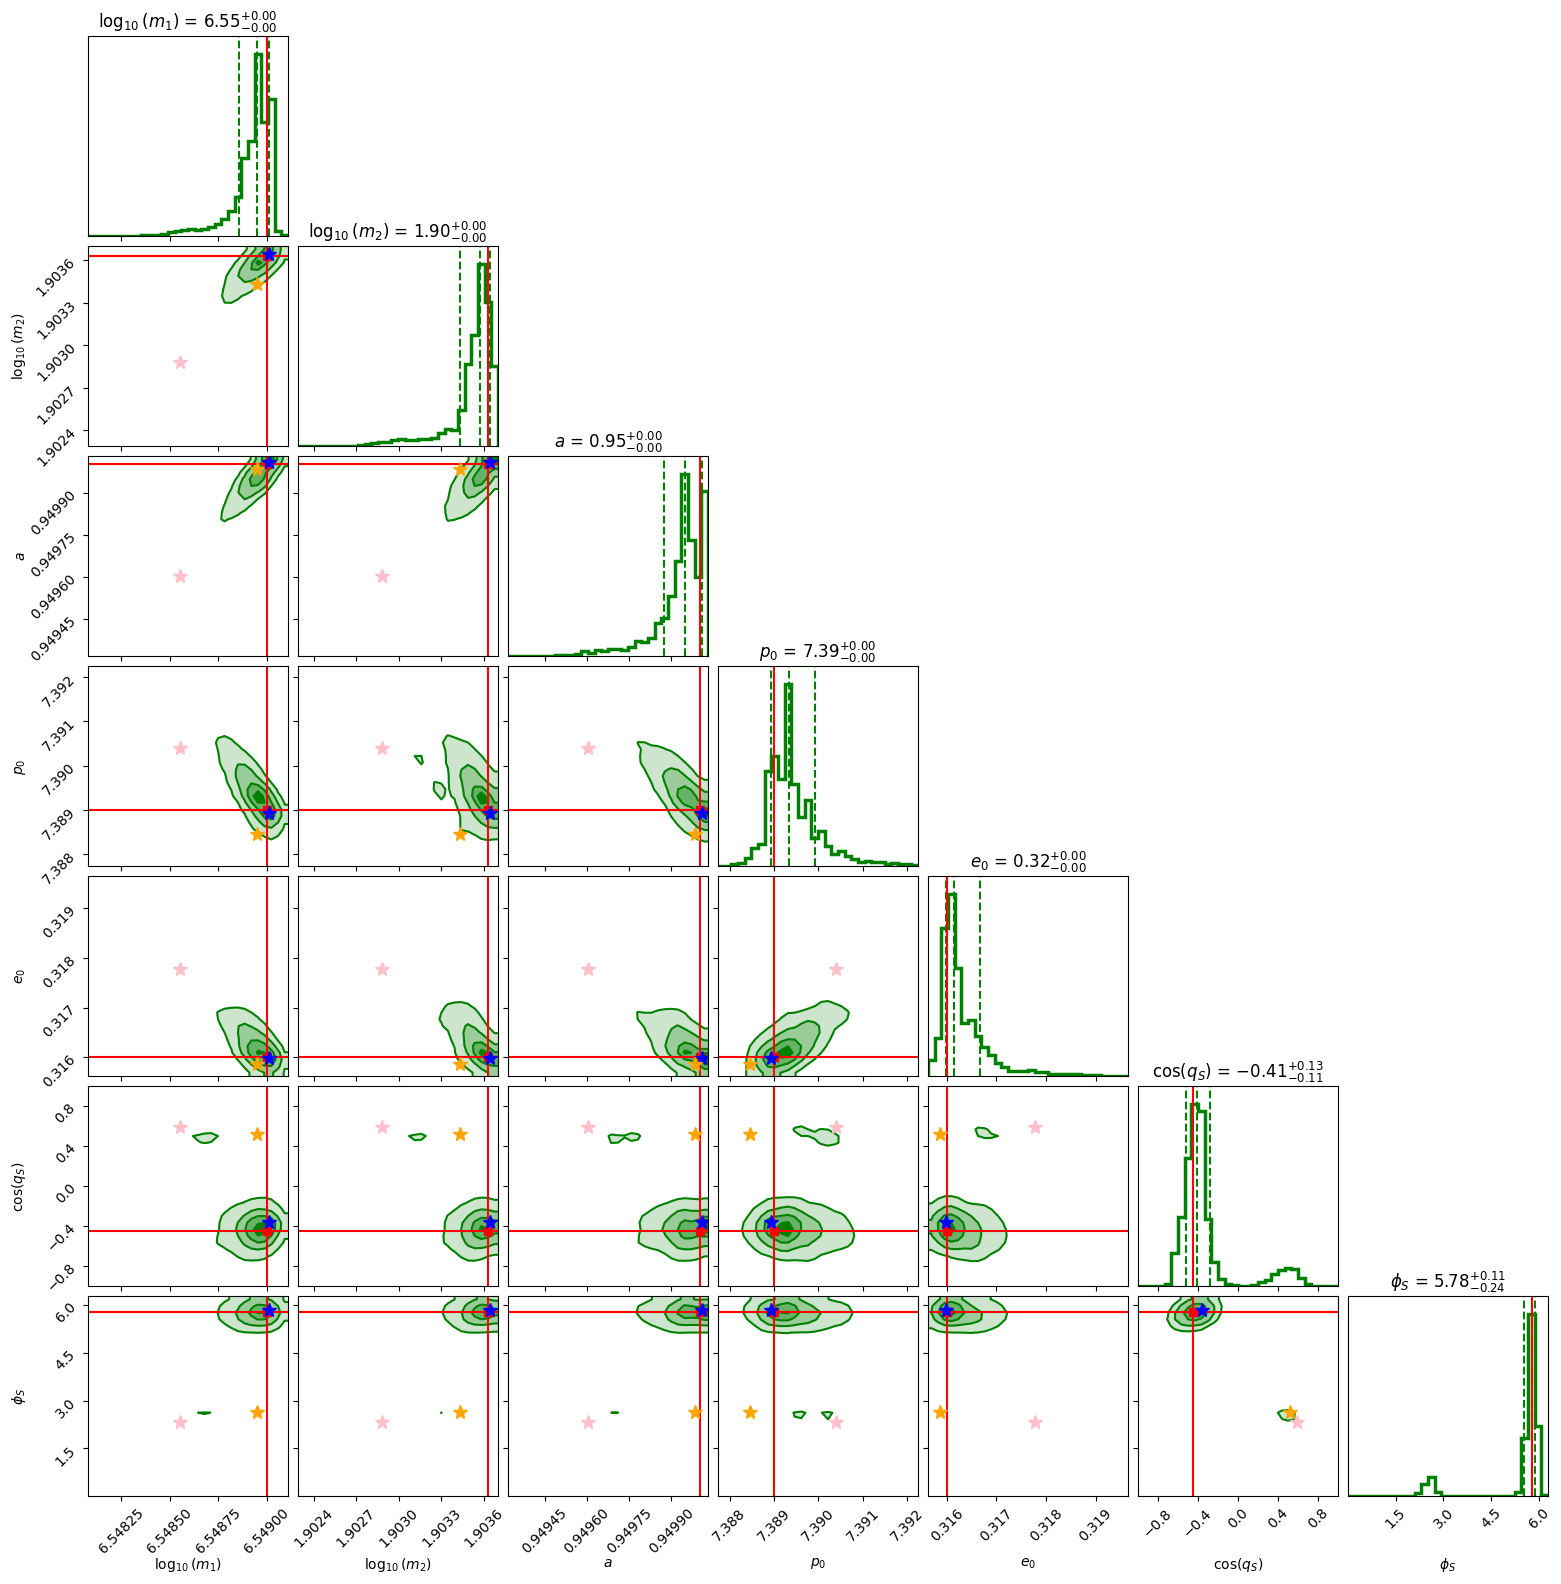

In [15]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$',r'$\cos(q_S)$', r'$\phi_S$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)

corner.overplot_points(fig, maxld_pt2.reshape(1, -1), 
                       color='orange', marker='*', ms=10, 
                       reverse=False)

corner.overplot_points(fig, maxld_pt3.reshape(1, -1), 
                       color='pink', marker='*', ms=10, 
                       reverse=False)

# corner.overplot_points(fig, maxld_pt4.reshape(1, -1),
#                        color='purple', marker='*', ms=10,
#                        reverse=False)

# corner.overplot_points(fig, maxld_pt5.reshape(1, -1),
#                        color='brown', marker='*', ms=10,
#                        reverse=False)

# corner.overplot_points(fig, maxld_pt6.reshape(1, -1),
#                        color='black', marker='*', ms=10,
#                        reverse=False)

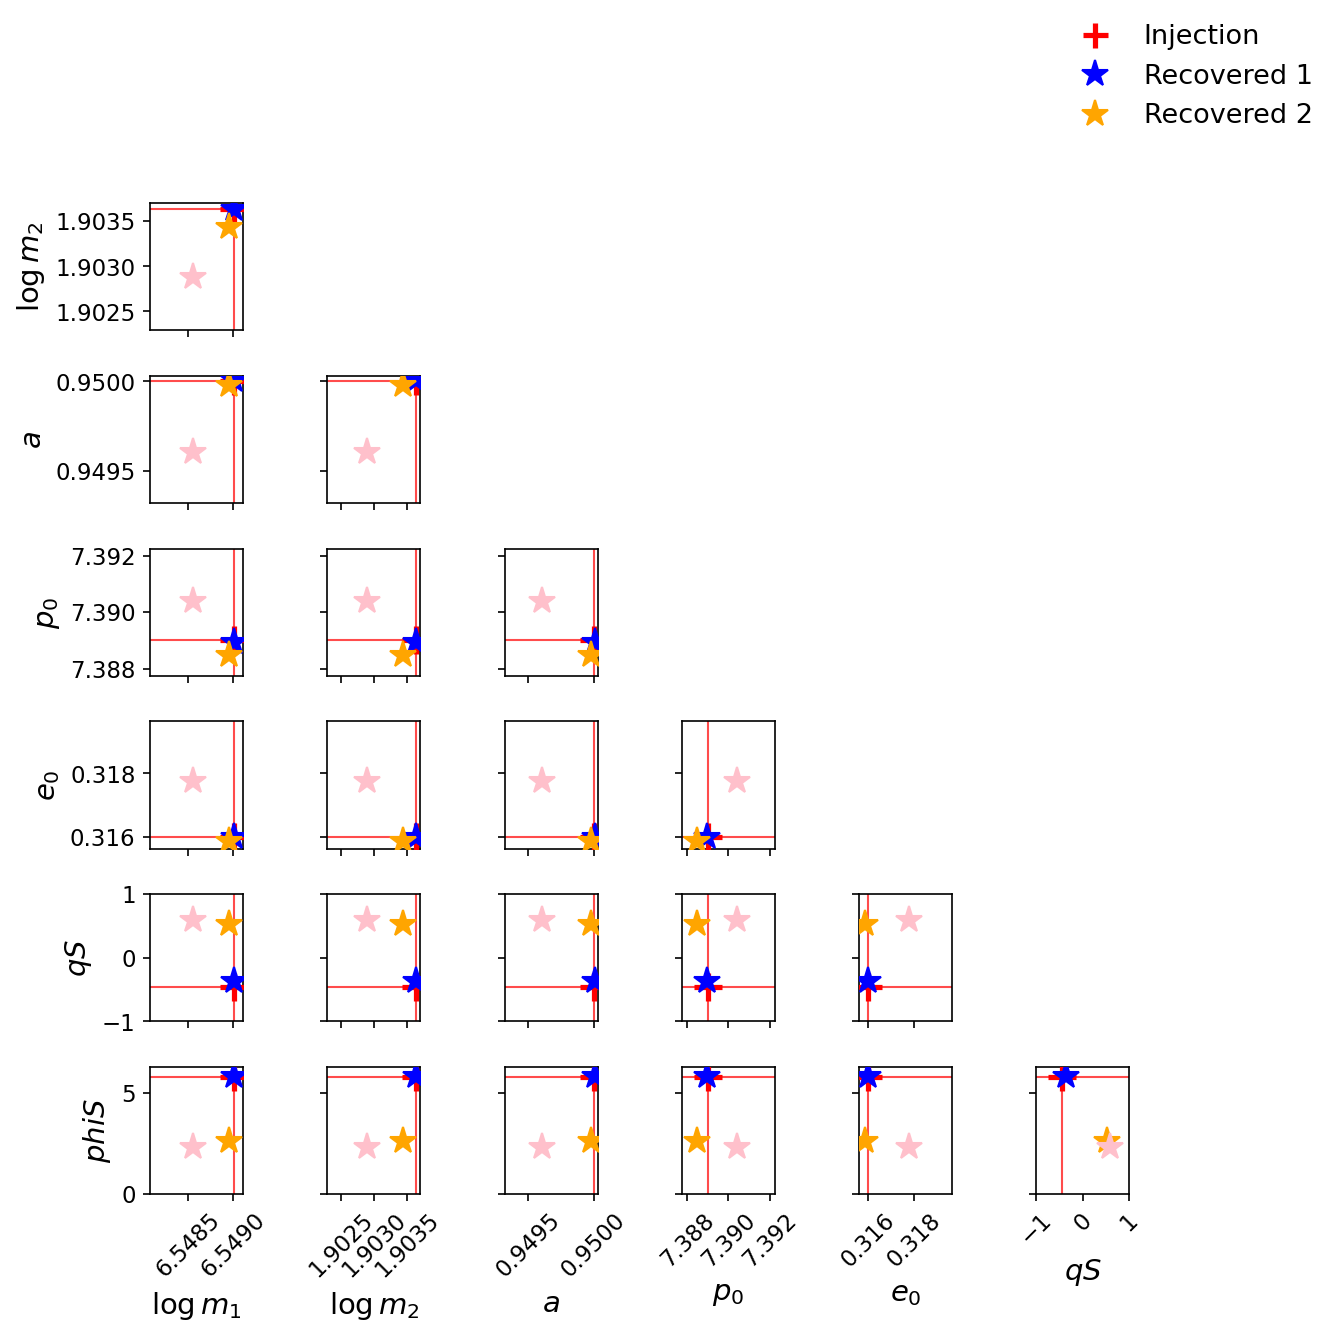

In [16]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({
    'font.size': 13, 'axes.labelsize': 14,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$', r'$qS$', r'$phiS$']
ndim = len(labels)

param_true = np.asarray(param_true).ravel()
maxld_pt1  = np.asarray(maxld_pt1).ravel()
maxld_pt2  = np.asarray(maxld_pt2).ravel()
maxld_pt3  = np.asarray(maxld_pt3).ravel()
# maxld_pt4  = np.asarray(maxld_pt4).ravel()
# maxld_pt5  = np.asarray(maxld_pt5).ravel()
# maxld_pt6  = np.asarray(maxld_pt6).ravel()

# full prior width per parameter: param_ranges = [(lo, hi), ...]
param_ranges = [tuple(r) for r in param_ranges]

fig, axes = plt.subplots(ndim, ndim, figsize=(9, 9))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        if j >= i:                       # blank diagonal + upper triangle
            ax.set_visible(False)
            continue

        # injection crosshairs + marker
        ax.axvline(param_true[j], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.axhline(param_true[i], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.plot(param_true[j], param_true[i], '+', color='red',
                ms=13, mew=2.5, zorder=3)

        # recovered MAP point
        ax.plot(maxld_pt1[j], maxld_pt1[i], '*', color='blue',
                ms=13, zorder=4)
        # recovered MAP point
        ax.plot(maxld_pt2[j], maxld_pt2[i], '*', color='orange',
                ms=13, zorder=4)
        # recovered MAP point
        ax.plot(maxld_pt3[j], maxld_pt3[i], '*', color='pink',
                ms=13, zorder=4)
        # ax.plot(maxld_pt4[j], maxld_pt4[i], '*', color='purple',
        #         ms=13, zorder=4)
        # ax.plot(maxld_pt5[j], maxld_pt5[i], '*', color='brown',
        #         ms=13, zorder=4)
        # ax.plot(maxld_pt6[j], maxld_pt6[i], '*', color='black',
        #         ms=13, zorder=4)
        # full prior width
        ax.set_xlim(*param_ranges[j])
        ax.set_ylim(*param_ranges[i])

        if j == 0:
            ax.set_ylabel(labels[i])
        else:
            ax.set_yticklabels([])
        if i == ndim - 1:
            ax.set_xlabel(labels[j])
            ax.tick_params(axis='x', rotation=45)
        else:
            ax.set_xticklabels([])

handles = [
    Line2D([0], [0], color='red',  marker='+', ls='', ms=12, mew=2.5, label='Injection'),
    Line2D([0], [0], color='blue', marker='*', ls='', ms=13,          label='Recovered 1'),
    Line2D([0], [0], color='orange', marker='*', ls='', ms=13,          label='Recovered 2'),
    # Line2D([0], [0], color='pink', marker='*', ls='', ms=13,          label='Recovered 3'),
]
fig.legend(handles=handles, loc='upper right', frameon=False, fontsize=13)
fig.tight_layout()

# connection plot to proc 1

In [17]:
proc1_maxld_pt = maxld_pt1.copy().reshape(1, -1)
proc1_maxld_pt

array([[ 6.54901194,  1.90364114,  0.95000945,  7.38894413,  0.3159886 ,
        -0.36372673,  5.8297268 ]])

In [18]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [19]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [20]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


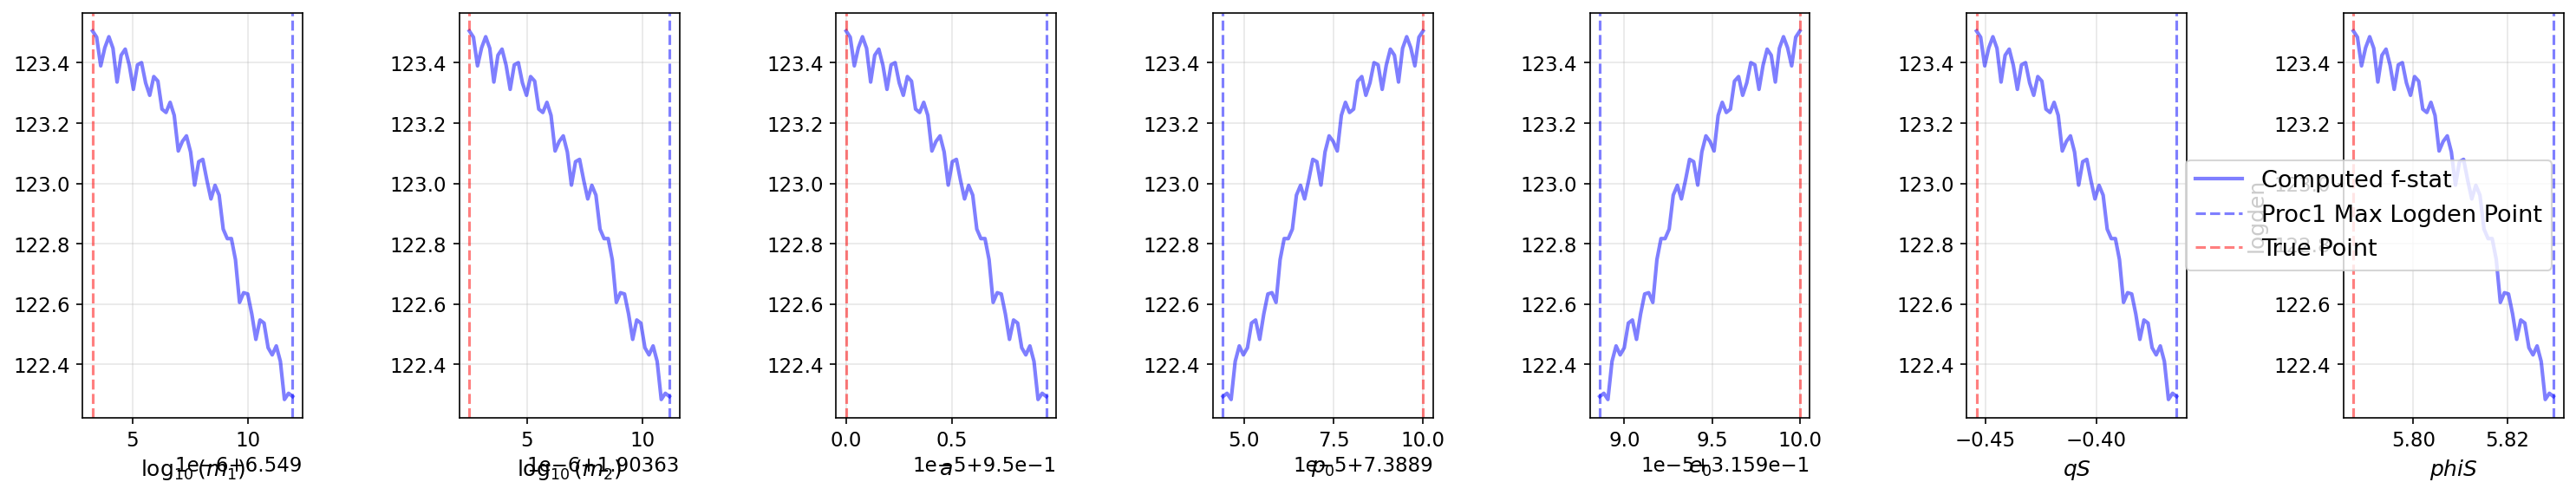

In [21]:
import matplotlib.pyplot as plt
fig_1d, axs_1d = plt.subplots(1, 7, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$qS$', r'$phiS$']
plt.ylabel('logden', fontsize=12)
for dim in range(7):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [22]:
import numpy as np

def sky_antipode(qS, phiS):
    """
    Antipodal sky point: qS -> pi - qS, phiS -> phiS + pi (mod 2pi).
    qS: colatitude [rad], phiS: azimuth [rad].
    """
    qS_anti = np.pi - qS
    phiS_anti = (phiS + np.pi) % (2 * np.pi)
    return qS_anti, phiS_anti

# EMRI_C true values
qS_true, phiS_true = 2.0420, 5.7873
qS_anti, phiS_anti = sky_antipode(qS_true, phiS_true)

print(f"qS_true={qS_true:.4f}  phiS_true={phiS_true:.4f}  cos(qS_true)={np.cos(qS_true):.5f}")
print(f"qS_anti={qS_anti:.4f}  phiS_anti={phiS_anti:.4f}  cos(qS_anti)={np.cos(qS_anti):.5f}")


qS_true=2.0420  phiS_true=5.7873  cos(qS_true)=-0.45396
qS_anti=1.0996  phiS_anti=2.6457  cos(qS_anti)=0.45396


In [23]:
maxld_pt1

array([ 6.54901194,  1.90364114,  0.95000945,  7.38894413,  0.3159886 ,
       -0.36372673,  5.8297268 ])